In [1]:
import pandas as pd
import numpy as np

# Directly specify the file path, as 'uploaded' is not defined.
# Re-using the successful parsing parameters from previous steps.
df = pd.read_csv('/content/fraudTest.csv', on_bad_lines='skip', engine='python')

df.shape

(58343, 23)

In [2]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1.371817e+09,33.986391,-81.200714,0.0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1.371817e+09,39.450498,-109.960431,0.0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1.371817e+09,40.495810,-74.196111,0.0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1.371817e+09,28.812398,-80.883061,0.0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1.371817e+09,44.959148,-85.884734,0.0


In [3]:
check_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values
})

check_table

,Column,Data Type,Missing Values
0,Unnamed: 0,int64,0
1,trans_date_trans_time,object,0
2,cc_num,int64,0
3,merchant,object,0
4,category,object,0
5,amt,float64,0
6,first,object,0
7,last,object,0
8,gender,object,0
9,street,object,0


In [4]:
df["is_fraud"].value_counts()

,count
is_fraud,
0.0,58108
1.0,234


In [5]:
df["is_fraud"].value_counts(normalize=True) * 100

,proportion
is_fraud,
0.0,99.598917
1.0,0.401083


In [6]:
data = df.copy()
data.shape

(58343, 23)

In [7]:
data["trans_date_trans_time"] = pd.to_datetime(data["trans_date_trans_time"], errors="coerce")
data["dob"] = pd.to_datetime(data["dob"], errors="coerce")

data[["trans_date_trans_time", "dob"]].head()

,trans_date_trans_time,dob
0,2020-06-21 12:14:25,1968-03-19
1,2020-06-21 12:14:33,1990-01-17
2,2020-06-21 12:14:53,1970-10-21
3,2020-06-21 12:15:15,1987-07-25
4,2020-06-21 12:15:17,1955-07-06


In [8]:
data["trans_hour"] = data["trans_date_trans_time"].dt.hour
data["trans_day"] = data["trans_date_trans_time"].dt.day
data["trans_month"] = data["trans_date_trans_time"].dt.month
data["trans_dayofweek"] = data["trans_date_trans_time"].dt.dayofweek
data["is_weekend"] = data["trans_dayofweek"].isin([5, 6]).astype(int)

data[["trans_hour", "trans_day", "trans_month", "trans_dayofweek", "is_weekend"]].head()

,trans_hour,trans_day,trans_month,trans_dayofweek,is_weekend
0,12,21,6,6,1
1,12,21,6,6,1
2,12,21,6,6,1
3,12,21,6,6,1
4,12,21,6,6,1


In [9]:
data["age"] = data["trans_date_trans_time"].dt.year - data["dob"].dt.year
data["log_amt"] = np.log1p(data["amt"])

data[["age", "amt", "log_amt"]].head()

,age,amt,log_amt
0,52,2.86,1.350667
1,30,29.84,3.428813
2,50,41.28,3.744314
3,33,60.05,4.111693
4,65,3.19,1.432701


In [10]:
location_cols = ["lat", "long", "merch_lat", "merch_long"]

for col in location_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data[location_cols].dtypes

,0
lat,float64
long,float64
merch_lat,float64
merch_long,float64


In [11]:
data[location_cols].isnull().sum()

,0
lat,0
long,0
merch_lat,1
merch_long,1


In [12]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1.astype(float))
    lon1 = np.radians(lon1.astype(float))
    lat2 = np.radians(lat2.astype(float))
    lon2 = np.radians(lon2.astype(float))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c

data["distance_km"] = haversine_distance(
    data["lat"],
    data["long"],
    data["merch_lat"],
    data["merch_long"]
)

data[["distance_km"]].head()

,distance_km
0,24.561462
1,104.925092
2,59.080078
3,27.698567
4,104.335106


In [13]:
data["distance_km"].describe()

,distance_km
count,58342.000000
mean,76.027925
std,29.008424
min,0.514151
25%,55.429111
50%,78.082281
75%,98.313698
max,148.210240


In [14]:
data["amt"] = pd.to_numeric(data["amt"], errors="coerce")

customer_stats = data.groupby("cc_num")["amt"].agg(["mean", "std", "count"]).reset_index()
customer_stats.columns = ["cc_num", "customer_avg_amt", "customer_std_amt", "customer_transaction_count"]

data = data.merge(customer_stats, on="cc_num", how="left")

data["customer_std_amt"] = data["customer_std_amt"].fillna(0)
data["amount_zscore_customer"] = (data["amt"] - data["customer_avg_amt"]) / (data["customer_std_amt"] + 1)

data[["amt", "customer_avg_amt", "customer_transaction_count", "amount_zscore_customer"]].head()

,amt,customer_avg_amt,customer_transaction_count,amount_zscore_customer
0,2.86,49.972973,74,-1.030692
1,29.84,44.924070,86,-0.335749
2,41.28,75.448571,105,-0.487704
3,60.05,56.285455,77,0.048171
4,3.19,58.216602,103,-0.518543


In [15]:
data.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'trans_hour', 'trans_day',
       'trans_month', 'trans_dayofweek', 'is_weekend', 'age', 'log_amt',
       'distance_km', 'customer_avg_amt', 'customer_std_amt',
       'customer_transaction_count', 'amount_zscore_customer'],
      dtype='object')

In [16]:
target = "is_fraud"

drop_columns = [
    "is_fraud",
    "Unnamed: 0",
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "trans_num",
    "unix_time",
    "cc_num"
]

X = data.drop(columns=drop_columns, errors="ignore")
y = data[target]

X.shape, y.shape

((58343, 25), (58343,))

In [17]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

len(numeric_features), len(categorical_features)

(19, 6)

In [18]:
numeric_features

['amt',
 'zip',
 'lat',
 'long',
 'city_pop',
 'merch_lat',
 'merch_long',
 'trans_hour',
 'trans_day',
 'trans_month',
 'trans_dayofweek',
 'is_weekend',
 'age',
 'log_amt',
 'distance_km',
 'customer_avg_amt',
 'customer_std_amt',
 'customer_transaction_count',
 'amount_zscore_customer']

In [19]:
categorical_features

['merchant', 'category', 'gender', 'city', 'state', 'job']

In [20]:
data["is_fraud"].isnull().sum()

np.int64(1)

In [21]:
data = data.dropna(subset=["is_fraud"])

data["is_fraud"].isnull().sum()

np.int64(0)

In [22]:
data["is_fraud"] = data["is_fraud"].astype(int)

data["is_fraud"].value_counts()

,count
is_fraud,
0,58108
1,234


In [23]:
target = "is_fraud"

drop_columns = [
    "is_fraud",
    "Unnamed: 0",
    "trans_date_trans_time",
    "dob",
    "first",
    "last",
    "street",
    "trans_num",
    "unix_time",
    "cc_num"
]

X = data.drop(columns=drop_columns, errors="ignore")
y = data[target]

X.shape, y.shape

((58342, 25), (58342,))

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((46673, 25), (11669, 25), (46673,), (11669,))

In [25]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

len(numeric_features), len(categorical_features)

(19, 6)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [27]:
from sklearn.tree import DecisionTreeClassifier

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ))
])

In [28]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['amt', 'zip', 'lat', 'long',
                                                   'city_pop', 'merch_lat',
                                                   'merch_long', 'trans_hour',
                                                   'trans_day', 'trans_month',
                                                   'trans_dayofweek',
                                                   'is_weekend', 'age',
                                                   'log_amt', 'distance_km',
                                                   'customer_avg_amt',
                                                   'customer_std_amt',
                                                   'customer_transaction_count',
                                                   'amount_zscore_customer']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['merchant', 'category',
                                                   'gender', 'city', 'state',
                                                   'job'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [29]:
baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

print(confusion_matrix(y_test, baseline_pred))
print(classification_report(y_test, baseline_pred))

baseline_roc_auc = roc_auc_score(y_test, baseline_prob)
baseline_pr_auc = average_precision_score(y_test, baseline_prob)

baseline_roc_auc, baseline_pr_auc

[[11439   183]
 [    2    45]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     11622
           1       0.20      0.96      0.33        47

    accuracy                           0.98     11669
   macro avg       0.60      0.97      0.66     11669
weighted avg       1.00      0.98      0.99     11669



(np.float64(0.9846851349421675), np.float64(0.38764833358910067))

In [31]:
!pip -q install xgboost

In [32]:
from xgboost import XGBClassifier

In [33]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

scale_pos_weight

np.float64(248.58823529411765)

In [34]:
modified_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

In [35]:
modified_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['amt', 'zip', 'lat', 'long',
                                                   'city_pop', 'merch_lat',
                                                   'merch_long', 'trans_hour',
                                                   'trans_day', 'trans_month',
                                                   'trans_dayofweek',
                                                   'is_weekend', 'age',
                                                   'log_amt', 'distance_km',
                                                   'customer_avg_amt',
                                                   'customer_std_amt',
                                                   'customer_transa...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.08,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [36]:
modified_pred = modified_model.predict(X_test)
modified_prob = modified_model.predict_proba(X_test)[:, 1]

In [37]:
print(confusion_matrix(y_test, modified_pred))
print(classification_report(y_test, modified_pred, zero_division=0))

modified_roc_auc = roc_auc_score(y_test, modified_prob)
modified_pr_auc = average_precision_score(y_test, modified_prob)

modified_roc_auc, modified_pr_auc

[[11613     9]
 [    5    42]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11622
           1       0.82      0.89      0.86        47

    accuracy                           1.00     11669
   macro avg       0.91      0.95      0.93     11669
weighted avg       1.00      1.00      1.00     11669



(np.float64(0.9996576558764193), np.float64(0.9462144097649566))

In [38]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, modified_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

best_threshold

np.float32(0.7760247)

In [39]:
threshold_pred = (modified_prob >= best_threshold).astype(int)

In [40]:
print(confusion_matrix(y_test, threshold_pred))
print(classification_report(y_test, threshold_pred, zero_division=0))

[[11618     4]
 [    7    40]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11622
           1       0.91      0.85      0.88        47

    accuracy                           1.00     11669
   macro avg       0.95      0.93      0.94     11669
weighted avg       1.00      1.00      1.00     11669



In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": [
        "Baseline Decision Tree",
        "Modified XGBoost",
        "Modified XGBoost Tuned"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, modified_pred),
        accuracy_score(y_test, threshold_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, modified_pred, zero_division=0),
        precision_score(y_test, threshold_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, modified_pred, zero_division=0),
        recall_score(y_test, threshold_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, modified_pred, zero_division=0),
        f1_score(y_test, threshold_pred, zero_division=0)
    ],
    "ROC AUC": [
        baseline_roc_auc,
        modified_roc_auc,
        modified_roc_auc
    ],
    "PR AUC": [
        baseline_pr_auc,
        modified_pr_auc,
        modified_pr_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Baseline Decision Tree,0.984146,0.197368,0.957447,0.327273,0.984685,0.387648
1,Modified XGBoost,0.998800,0.823529,0.893617,0.857143,0.999658,0.946214
2,Modified XGBoost Tuned,0.999057,0.909091,0.851064,0.879121,0.999658,0.946214


In [42]:
results.to_csv("benchmarking_results.csv", index=False)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Baseline Decision Tree,0.984146,0.197368,0.957447,0.327273,0.984685,0.387648
1,Modified XGBoost,0.998800,0.823529,0.893617,0.857143,0.999658,0.946214
2,Modified XGBoost Tuned,0.999057,0.909091,0.851064,0.879121,0.999658,0.946214


In [43]:
import joblib

joblib.dump(modified_model, "modified_xgboost_model.pkl")

['modified_xgboost_model.pkl']

In [44]:
from google.colab import files

files.download("benchmarking_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
files.download("modified_xgboost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
prediction_results = X_test.copy()
prediction_results["actual_value"] = y_test.values
prediction_results["predicted_value"] = threshold_pred
prediction_results["fraud_probability"] = modified_prob

prediction_results.head()

,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,...,age,log_amt,distance_km,customer_avg_amt,customer_std_amt,customer_transaction_count,amount_zscore_customer,actual_value,predicted_value,fraud_probability
14374,fraud_Stiedemann Inc,misc_pos,588.67,F,Eugene,OR,97403,44.0385,-123.0614,191096,...,56,6.379563,31.811448,53.193649,77.298582,74,6.838902,0,0,0.000009
21127,fraud_Zulauf LLC,personal_care,38.38,F,Campbell,NE,68932,40.2967,-98.7370,493,...,80,3.673258,35.712566,47.881892,49.325570,74,-0.188808,0,0,0.000012
5614,"fraud_Hills, Hegmann and Schaefer",health_fitness,42.64,F,Hannawa Falls,NY,13647,44.6087,-74.9732,69,...,29,3.775974,126.565076,48.749658,85.174412,117,-0.070899,0,0,0.000003
14582,fraud_Luettgen PLC,gas_transport,87.40,F,Walnut Ridge,AR,72476,36.0244,-90.9288,7155,...,43,4.481872,45.284243,97.830608,132.458808,148,-0.078156,0,0,0.000002
52988,fraud_Leffler-Goldner,personal_care,106.51,M,Falmouth,MI,49632,44.2529,-85.0170,1126,...,65,4.677584,119.275330,58.216602,105.117640,103,0.455093,0,0,0.000004


In [47]:
prediction_results.to_csv("prediction_evidence.csv", index=False)

files.download("prediction_evidence.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
importance_values = modified_model.named_steps["model"].feature_importances_

feature_names = numeric_features + categorical_features

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
16,customer_std_amt,0.566516
15,customer_avg_amt,0.089281
1,zip,0.079412
7,trans_hour,0.033519
13,log_amt,0.032623
18,amount_zscore_customer,0.029662
0,amt,0.028883
4,city_pop,0.019933
24,job,0.017655
3,long,0.011051


In [49]:
feature_importance.to_csv("feature_importance.csv", index=False)

files.download("feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
summary = pd.DataFrame({
    "Item": [
        "Dataset rows",
        "Dataset columns",
        "Training rows",
        "Testing rows",
        "Baseline model",
        "Modified model",
        "Best threshold"
    ],
    "Value": [
        data.shape[0],
        data.shape[1],
        X_train.shape[0],
        X_test.shape[0],
        "Decision Tree",
        "XGBoost",
        best_threshold
    ]
})

summary

,Item,Value
0,Dataset rows,58342
1,Dataset columns,35
2,Training rows,46673
3,Testing rows,11669
4,Baseline model,Decision Tree
5,Modified model,XGBoost
6,Best threshold,0.776025


In [51]:
summary.to_csv("final_evidence_summary.csv", index=False)

files.download("final_evidence_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [52]:
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Baseline Decision Tree,0.984146,0.197368,0.957447,0.327273,0.984685,0.387648
1,Modified XGBoost,0.998800,0.823529,0.893617,0.857143,0.999658,0.946214
2,Modified XGBoost Tuned,0.999057,0.909091,0.851064,0.879121,0.999658,0.946214


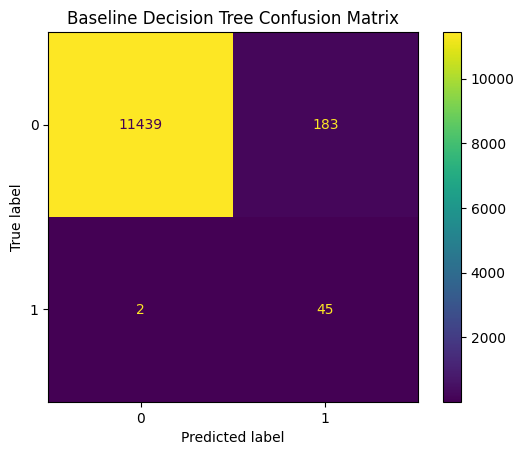

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, baseline_pred)
plt.title("Baseline Decision Tree Confusion Matrix")
plt.show()

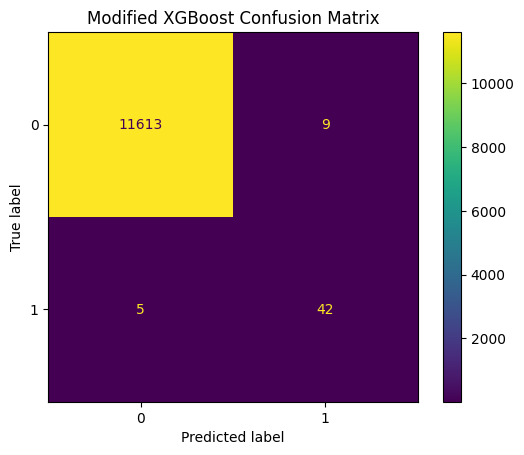

In [54]:
ConfusionMatrixDisplay.from_predictions(y_test, modified_pred)
plt.title("Modified XGBoost Confusion Matrix")
plt.show()

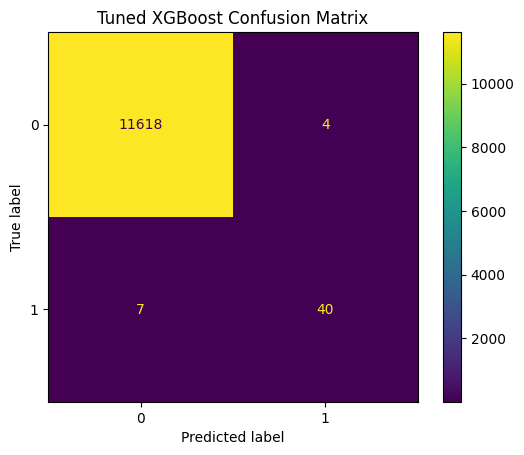

In [55]:
ConfusionMatrixDisplay.from_predictions(y_test, threshold_pred)
plt.title("Tuned XGBoost Confusion Matrix")
plt.show()

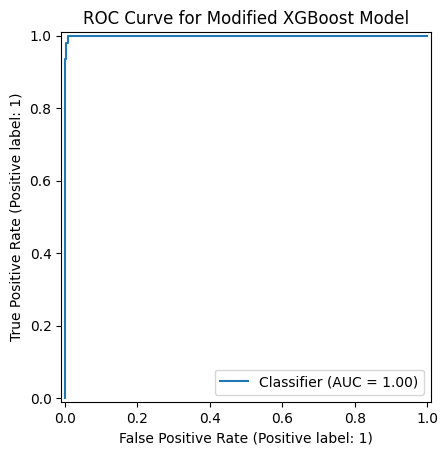

In [56]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, modified_prob)
plt.title("ROC Curve for Modified XGBoost Model")
plt.show()

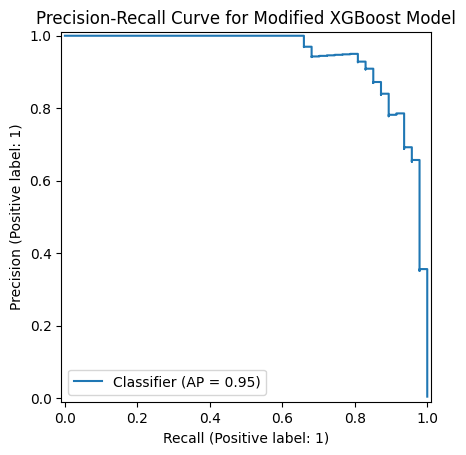

In [57]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, modified_prob)
plt.title("Precision-Recall Curve for Modified XGBoost Model")
plt.show()

In [58]:
feature_importance.head(15)

,Feature,Importance
16,customer_std_amt,0.566516
15,customer_avg_amt,0.089281
1,zip,0.079412
7,trans_hour,0.033519
13,log_amt,0.032623
18,amount_zscore_customer,0.029662
0,amt,0.028883
4,city_pop,0.019933
24,job,0.017655
3,long,0.011051


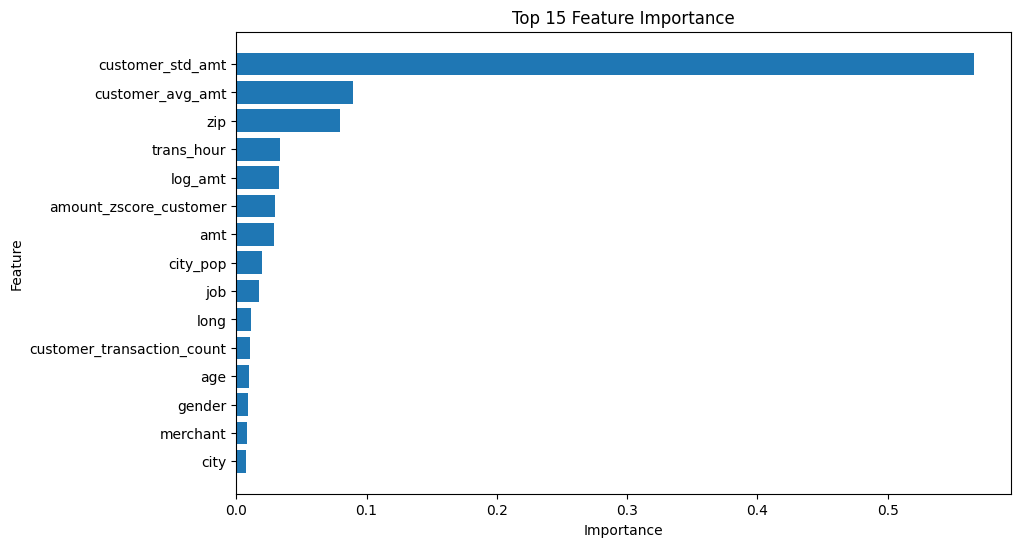

In [59]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [60]:
sample_predictions = prediction_results[
    ["actual_value", "predicted_value", "fraud_probability"]
].head(20)

sample_predictions

,actual_value,predicted_value,fraud_probability
14374,0,0,0.000009
21127,0,0,0.000012
5614,0,0,0.000003
14582,0,0,0.000002
52988,0,0,0.000004
2592,0,0,0.000002
57084,0,0,0.000021
27059,0,0,0.000017
47770,0,0,0.000004
38492,0,0,0.000155


In [61]:
import os

os.makedirs("final_ai_portfolio_outputs", exist_ok=True)

results.to_csv("final_ai_portfolio_outputs/benchmarking_results.csv", index=False)
prediction_results.to_csv("final_ai_portfolio_outputs/prediction_evidence.csv", index=False)
feature_importance.to_csv("final_ai_portfolio_outputs/feature_importance.csv", index=False)
summary.to_csv("final_ai_portfolio_outputs/final_evidence_summary.csv", index=False)
joblib.dump(modified_model, "final_ai_portfolio_outputs/modified_xgboost_model.pkl")

['final_ai_portfolio_outputs/modified_xgboost_model.pkl']

In [62]:
import shutil

shutil.make_archive("final_ai_portfolio_outputs", "zip", "final_ai_portfolio_outputs")

'/content/final_ai_portfolio_outputs.zip'

In [63]:
files.download("final_ai_portfolio_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
one_sample = X_test.iloc[[0]]

one_prediction = modified_model.predict(one_sample)
one_probability = modified_model.predict_proba(one_sample)[:, 1]

one_prediction, one_probability

(array([0]), array([9.277522e-06], dtype=float32))

In [65]:
one_tuned_prediction = (one_probability >= best_threshold).astype(int)

one_tuned_prediction

array([0])

In [66]:
final_test = pd.DataFrame({
    "Actual": [y_test.iloc[0]],
    "Default Prediction": [one_prediction[0]],
    "Tuned Prediction": [one_tuned_prediction[0]],
    "Fraud Probability": [one_probability[0]],
    "Best Threshold": [best_threshold]
})

final_test

,Actual,Default Prediction,Tuned Prediction,Fraud Probability,Best Threshold
0,0,0,0,0.000009,0.776025


In [67]:
final_test.to_csv("single_prediction_test.csv", index=False)

files.download("single_prediction_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
loaded_model = joblib.load("modified_xgboost_model.pkl")

loaded_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['amt', 'zip', 'lat', 'long',
                                                   'city_pop', 'merch_lat',
                                                   'merch_long', 'trans_hour',
                                                   'trans_day', 'trans_month',
                                                   'trans_dayofweek',
                                                   'is_weekend', 'age',
                                                   'log_amt', 'distance_km',
                                                   'customer_avg_amt',
                                                   'customer_std_amt',
                                                   'customer_transa...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.08,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [69]:
loaded_prediction = loaded_model.predict(X_test.iloc[[0]])
loaded_probability = loaded_model.predict_proba(X_test.iloc[[0]])[:, 1]

loaded_prediction, loaded_probability

(array([0]), array([9.277522e-06], dtype=float32))

In [70]:
def predict_transactions(input_data):
    probabilities = loaded_model.predict_proba(input_data)[:, 1]
    predictions = (probabilities >= best_threshold).astype(int)
    output = input_data.copy()
    output["fraud_probability"] = probabilities
    output["predicted_fraud"] = predictions
    return output

In [71]:
batch_test = X_test.head(10)

batch_output = predict_transactions(batch_test)

batch_output[["fraud_probability", "predicted_fraud"]]

,fraud_probability,predicted_fraud
14374,0.000009,0
21127,0.000012,0
5614,0.000003,0
14582,0.000002,0
52988,0.000004,0
2592,0.000002,0
57084,0.000021,0
27059,0.000017,0
47770,0.000004,0
38492,0.000155,0


In [72]:
batch_output.to_csv("batch_prediction_output.csv", index=False)

files.download("batch_prediction_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
prediction_results["risk_level"] = np.where(
    prediction_results["fraud_probability"] >= best_threshold,
    "High Risk",
    "Low Risk"
)

prediction_results[["actual_value", "predicted_value", "fraud_probability", "risk_level"]].head(20)

,actual_value,predicted_value,fraud_probability,risk_level
14374,0,0,0.000009,Low Risk
21127,0,0,0.000012,Low Risk
5614,0,0,0.000003,Low Risk
14582,0,0,0.000002,Low Risk
52988,0,0,0.000004,Low Risk
2592,0,0,0.000002,Low Risk
57084,0,0,0.000021,Low Risk
27059,0,0,0.000017,Low Risk
47770,0,0,0.000004,Low Risk
38492,0,0,0.000155,Low Risk


In [74]:
prediction_results.to_csv("risk_labelled_predictions.csv", index=False)

files.download("risk_labelled_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
final_model_report = pd.DataFrame({
    "Metric": [
        "Best Threshold",
        "Baseline ROC AUC",
        "Baseline PR AUC",
        "Modified ROC AUC",
        "Modified PR AUC",
        "Testing Records"
    ],
    "Value": [
        best_threshold,
        baseline_roc_auc,
        baseline_pr_auc,
        modified_roc_auc,
        modified_pr_auc,
        X_test.shape[0]
    ]
})

final_model_report

,Metric,Value
0,Best Threshold,0.776025
1,Baseline ROC AUC,0.984685
2,Baseline PR AUC,0.387648
3,Modified ROC AUC,0.999658
4,Modified PR AUC,0.946214
5,Testing Records,11669.000000


In [76]:
final_model_report.to_csv("final_model_report.csv", index=False)

files.download("final_model_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:
!pip -q install gradio

In [78]:
import gradio as gr

In [79]:
def gradio_predict(file):
    input_df = pd.read_csv(file.name)
    output_df = predict_transactions(input_df)
    output_path = "gradio_prediction_output.csv"
    output_df.to_csv(output_path, index=False)
    return output_path

In [80]:
app = gr.Interface(
    fn=gradio_predict,
    inputs=gr.File(label="Upload Transaction CSV"),
    outputs=gr.File(label="Download Prediction Output"),
    title="AgriSmart Subsidy Transaction Anomaly Detection System"
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://13552b49d1803dc31a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [81]:
!pip -q install shap

In [82]:
import shap

In [83]:
X_test_transformed = preprocessor.transform(X_test)

In [84]:
explainer = shap.TreeExplainer(modified_model.named_steps["model"])

In [85]:
shap_values = explainer.shap_values(X_test_transformed[:500])

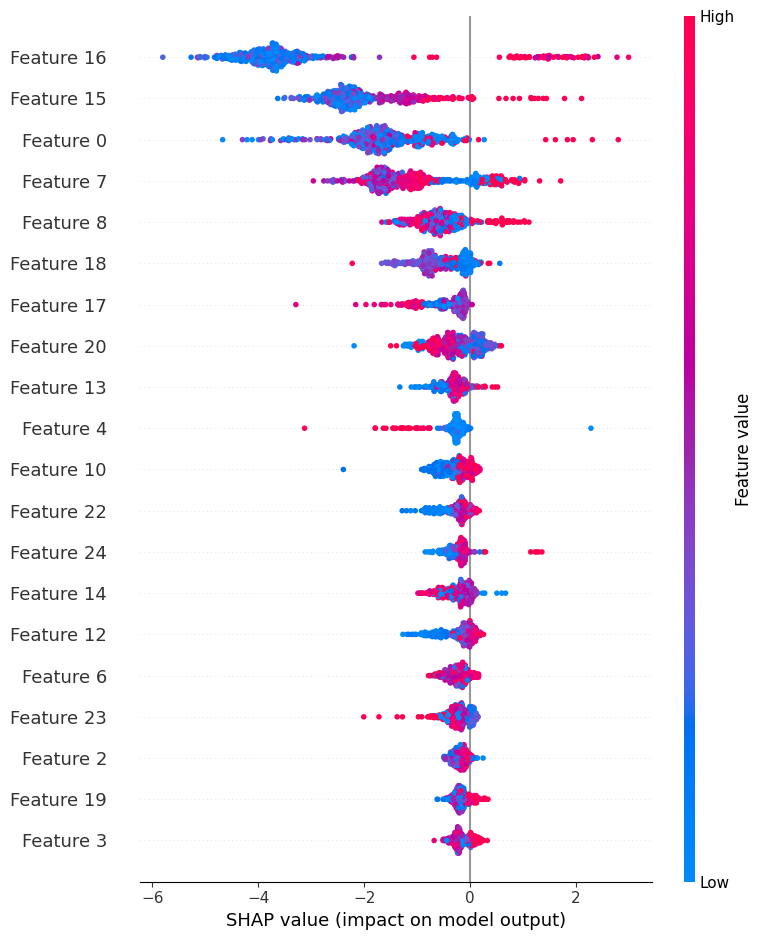

In [86]:
shap.summary_plot(
    shap_values,
    X_test_transformed[:500]
)

<Figure size 600x600 with 0 Axes>

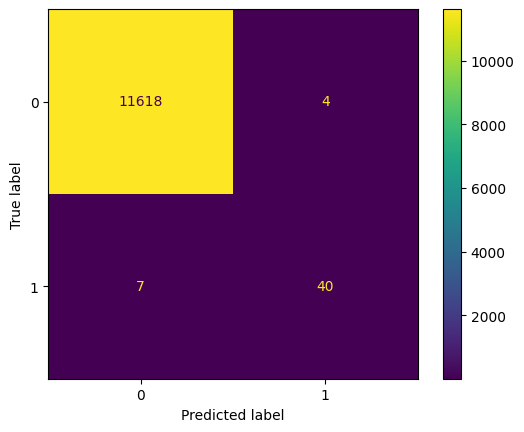

In [87]:
plt.figure(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(y_test, threshold_pred)
plt.savefig("confusion_matrix.png", bbox_inches="tight")
plt.show()

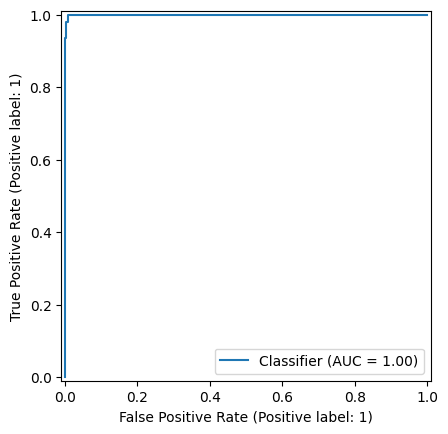

In [88]:
RocCurveDisplay.from_predictions(y_test, modified_prob)
plt.savefig("roc_curve.png", bbox_inches="tight")
plt.show()

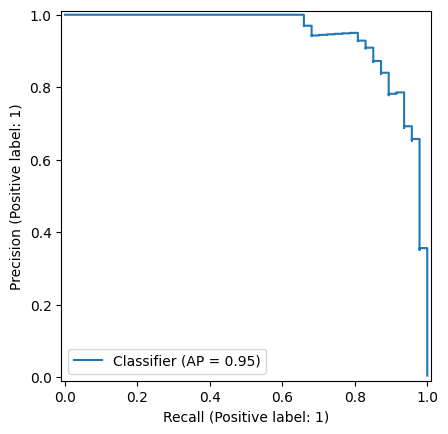

In [89]:
PrecisionRecallDisplay.from_predictions(y_test, modified_prob)
plt.savefig("precision_recall_curve.png", bbox_inches="tight")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import os
os.listdir()

In [ ]:
import os
os.listdir()

In [ ]:
import pandas as pd

file_path = r"Fraud Test (1).csv"
df = pd.read_csv(file_path)
df.head()

In [ ]:
df = pd.read_csv("Fraud_Test_1.csv")
df.head()